In [1568]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score
import pickle



In [1569]:
df = pd.read_csv("../data/processed/df_final_poblacion.csv")

In [1570]:
df[df["Municipio"] == "Barcelona"]["Poblacion"].unique()


<StringArray>
['1608746', '5542680', '1620809', '5576037', '1620343', '5609350', '1636762',
 '5664579', '1664182', '5743402', '1636732', '5714730', '1636193', '5727615',
 '1660122', '5805500', '1702547', '5899063', '1731649', '5983325']
Length: 20, dtype: str

In [1571]:
df["Poblacion"] = df["Poblacion"].str.replace(",", "")
df = df[df["Poblacion"].astype(int) < 3000000]
df[df["Municipio"] == "Barcelona"]

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
5028,Barcelona,Daños,2016,Enero-Marzo,1,Barcelona,2252,2252.0,1608746
5030,Barcelona,Daños,2016,Enero-Junio,2,Barcelona,4619,2367.0,1608746
5032,Barcelona,Daños,2016,Enero-Septiembre,3,Barcelona,6992,2373.0,1608746
5034,Barcelona,Daños,2016,Enero-Diciembre,4,Barcelona,9155,2163.0,1608746
5036,Barcelona,Delitos Sexuales,2017,Enero-Marzo,1,Barcelona,180,180.0,1620809
...,...,...,...,...,...,...,...,...,...
5664,Barcelona,Trafico De Drogas,2024,Enero-Septiembre,3,Barcelona,1410,452.0,1702547
5666,Barcelona,Trafico De Drogas,2024,Enero-Diciembre,4,Barcelona,1887,477.0,1702547
5668,Barcelona,Trafico De Drogas,2025,Enero-Marzo,1,Barcelona,572,572.0,1731649
5670,Barcelona,Trafico De Drogas,2025,Enero-Junio,2,Barcelona,1210,638.0,1731649


### Construccion fecha

In [1572]:
trimestre_fecha = {
    1:"03-31",
    2:"06-30",
    3:"09-30",
    4:"12-31"
} 
df["fecha_str"] = df.apply(lambda fila: f"{fila["Año"]}-{trimestre_fecha[fila["Trimestre"]]}", axis=1)

df["fecha"] = pd.to_datetime(df["fecha_str"])


In [1573]:
df[(df["Año"].isin([2016,2017])) & (df["Total"] > 2000)]

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion,fecha_str,fecha
418,Alcalá de Henares,Hurtos,2016,Enero-Septiembre,3,Madrid,2138,678.0,195907,2016-09-30,2016-09-30
419,Alcalá de Henares,Hurtos,2016,Enero-Diciembre,4,Madrid,2801,663.0,195907,2016-12-31,2016-12-31
422,Alcalá de Henares,Hurtos,2017,Enero-Septiembre,3,Madrid,2078,663.0,194310,2017-09-30,2017-09-30
423,Alcalá de Henares,Hurtos,2017,Enero-Diciembre,4,Madrid,2676,598.0,194310,2017-12-31,2017-12-31
1065,Alcorcón,Hurtos,2016,Enero-Diciembre,4,Madrid,2469,675.0,167354,2016-12-31,2016-12-31
...,...,...,...,...,...,...,...,...,...,...,...
33136,Valencia,Hurtos,2017,Enero-Marzo,1,Valencia,5025,5025.0,2540707,2017-03-31,2017-03-31
33137,Valencia,Hurtos,2017,Enero-Septiembre,3,Valencia,14205,9180.0,2540707,2017-09-30,2017-09-30
33138,Valencia,Hurtos,2017,Enero-Diciembre,4,Valencia,18624,4419.0,2540707,2017-12-31,2017-12-31
33201,Valencia,Robos Con Fuerza,2017,Enero-Septiembre,3,Valencia,3259,2349.0,2540707,2017-09-30,2017-09-30


### Convertir fecha a indice

In [1574]:
df = df.sort_values("fecha")
df = df.set_index("fecha")
df = df.copy()

In [1575]:
df

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion,fecha_str
fecha,,,,,,,,,,
2016-03-31,Gandia,Hurtos,2016,Enero-Marzo,1,Valencia,323,323.0,74814,2016-03-31
2016-03-31,Manresa,Daños,2016,Enero-Marzo,1,Barcelona,87,87.0,74752,2016-03-31
2016-03-31,Valencia,Hurtos,2016,Enero-Marzo,1,Valencia,5132,5132.0,2544264,2016-03-31
2016-03-31,Torrent,Hurtos,2016,Enero-Marzo,1,Valencia,227,227.0,80762,2016-03-31
2016-03-31,Castelldefels,Hurtos,2016,Enero-Marzo,1,Barcelona,207,207.0,64892,2016-03-31
...,...,...,...,...,...,...,...,...,...,...
2025-09-30,Mutxamel,Secuestro,2025,Enero-Septiembre,3,Alicante,0,0.0,28621,2025-09-30
2025-09-30,Mutxamel,Sustraccion De Vehiculos,2025,Enero-Septiembre,3,Alicante,3,1.0,28621,2025-09-30
2025-09-30,Mutxamel,Trafico De Drogas,2025,Enero-Septiembre,3,Alicante,5,2.0,28621,2025-09-30


### Eliminar columnas que ya no aportan

In [1576]:
df = df.drop(columns=["Año","fecha_str"])
#df = df[df.index.year != 2025]
df

,Municipio,Delitos,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
fecha,,,,,,,,
2016-03-31,Gandia,Hurtos,Enero-Marzo,1,Valencia,323,323.0,74814
2016-03-31,Manresa,Daños,Enero-Marzo,1,Barcelona,87,87.0,74752
2016-03-31,Valencia,Hurtos,Enero-Marzo,1,Valencia,5132,5132.0,2544264
2016-03-31,Torrent,Hurtos,Enero-Marzo,1,Valencia,227,227.0,80762
2016-03-31,Castelldefels,Hurtos,Enero-Marzo,1,Barcelona,207,207.0,64892
...,...,...,...,...,...,...,...,...
2025-09-30,Mutxamel,Secuestro,Enero-Septiembre,3,Alicante,0,0.0,28621
2025-09-30,Mutxamel,Sustraccion De Vehiculos,Enero-Septiembre,3,Alicante,3,1.0,28621
2025-09-30,Mutxamel,Trafico De Drogas,Enero-Septiembre,3,Alicante,5,2.0,28621


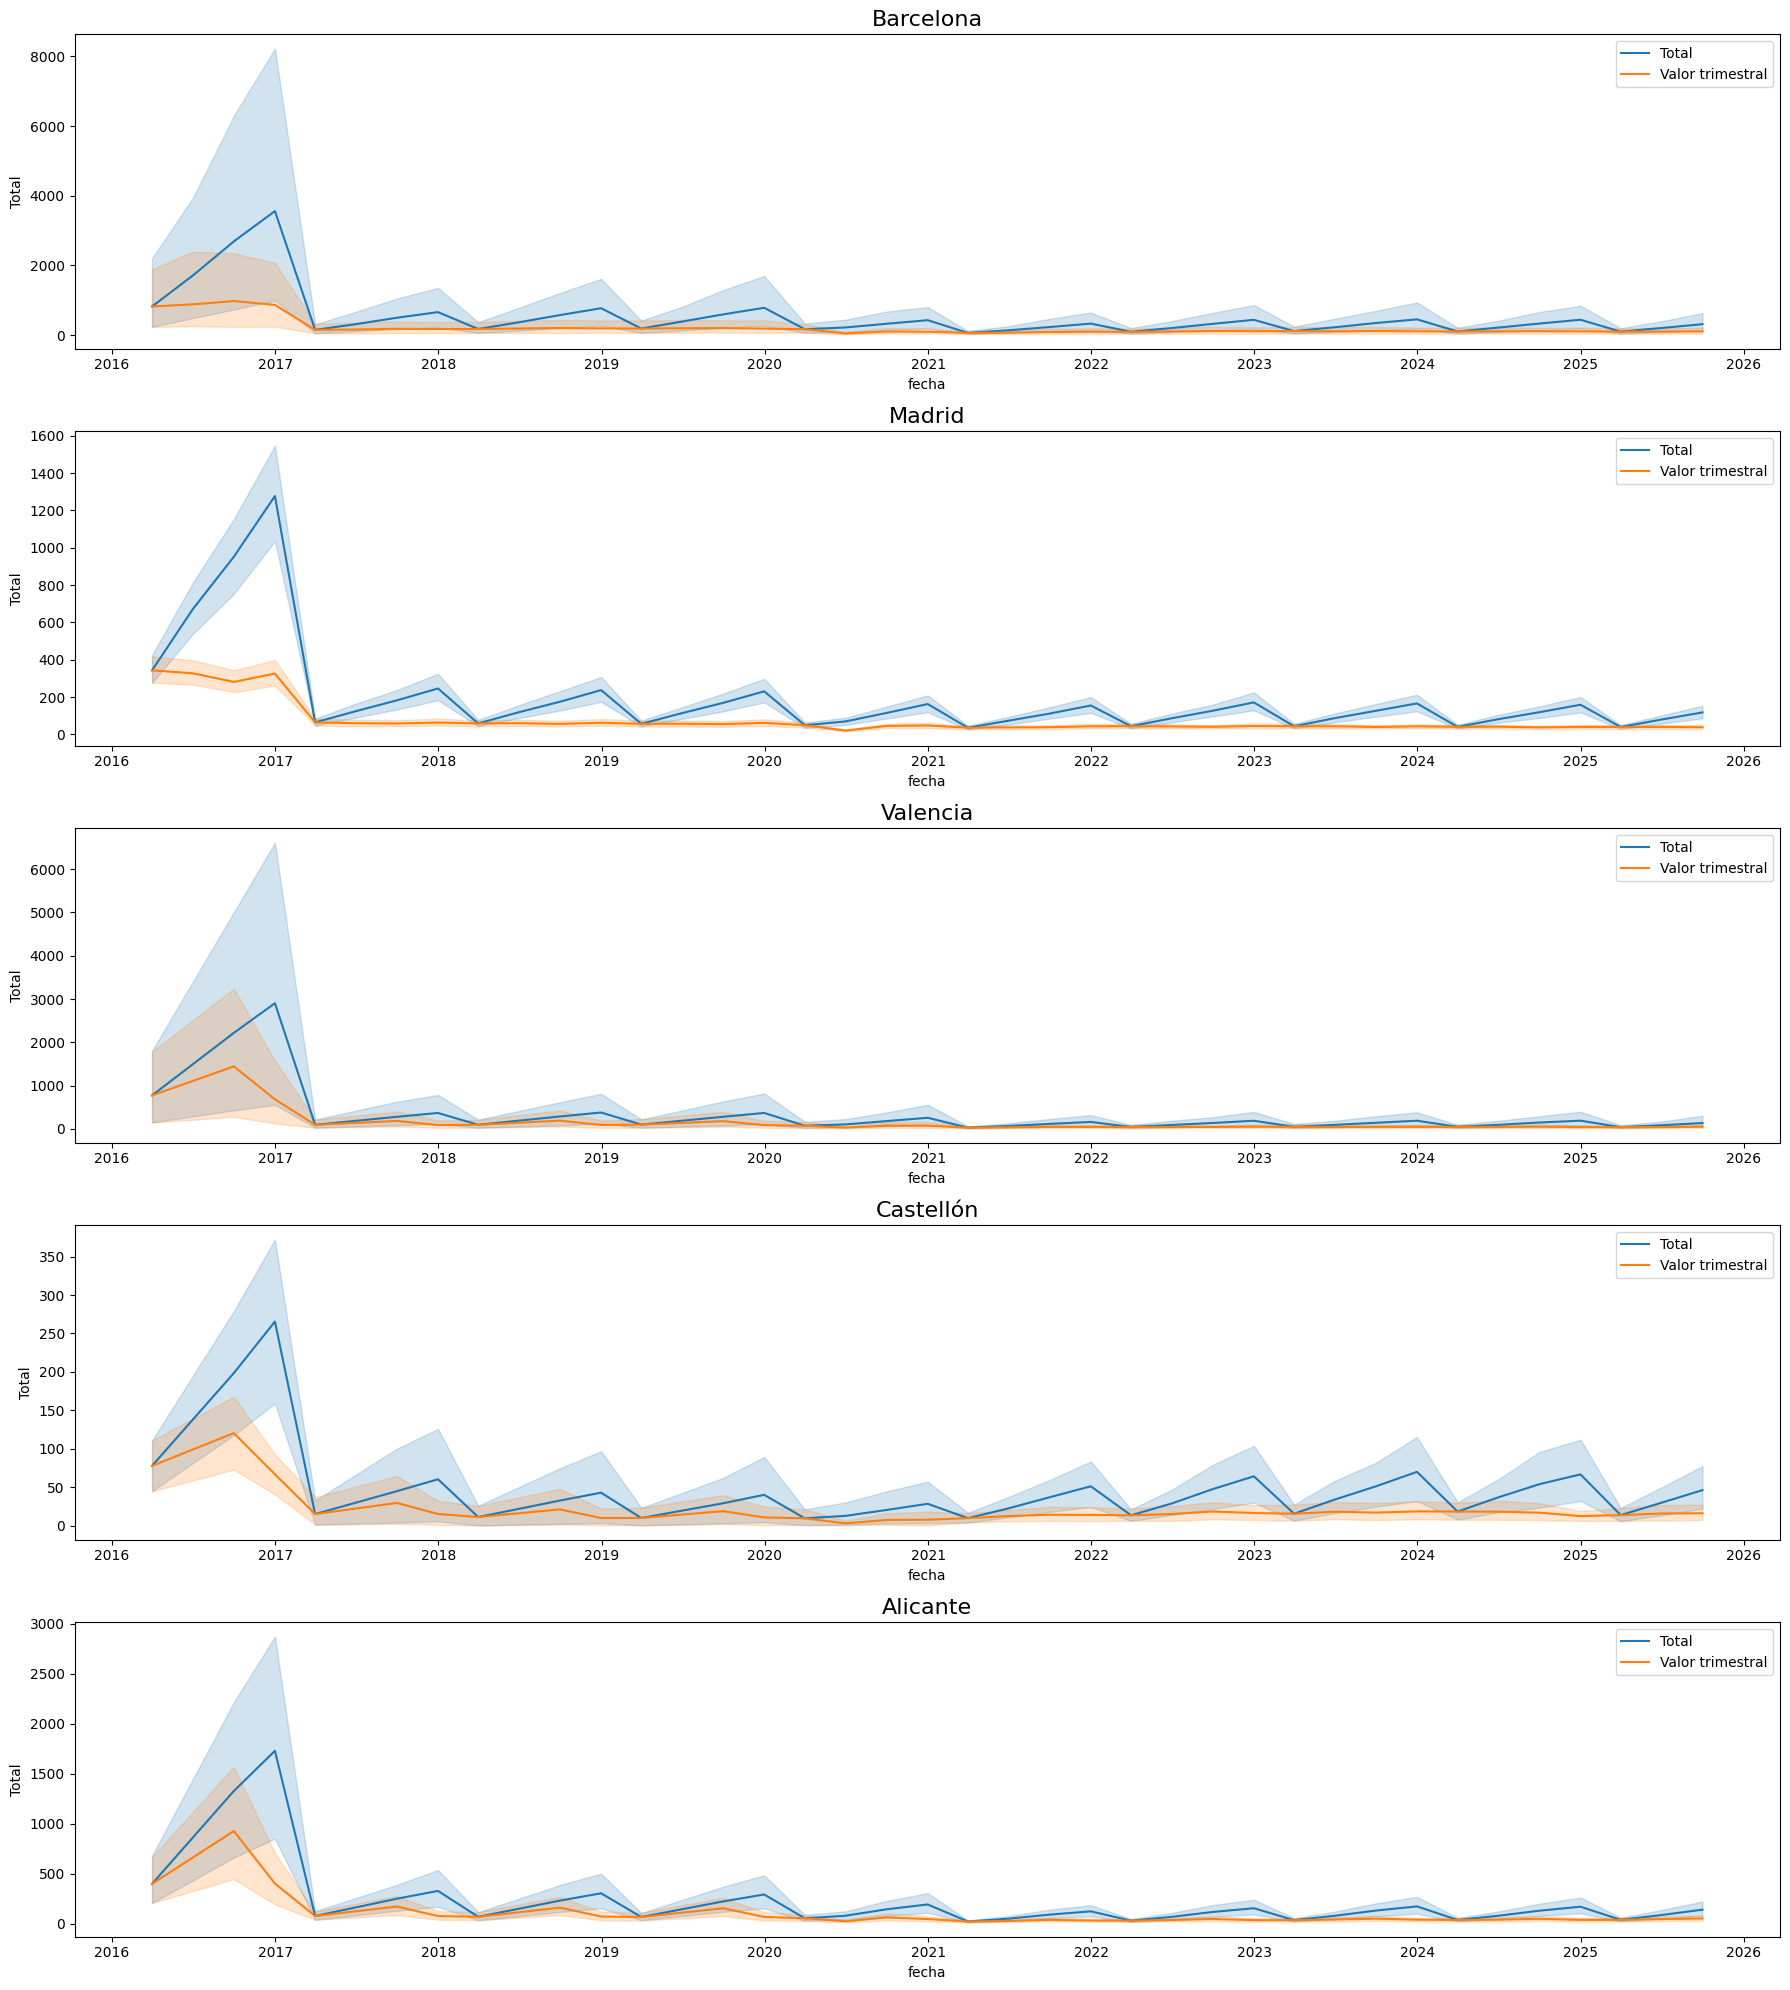

In [1577]:
# Filtrado por provincia
barcelona = df[df["Provincia"] == "Barcelona"]
madrid = df[df["Provincia"] == "Madrid"]
valencia = df[df["Provincia"] == "Valencia"]
castellon = df[df["Provincia"] == "Castellón"]
alicante = df[df["Provincia"] == "Alicante"]

# Lista de dataframes y nombres
dfs = [barcelona, madrid, valencia, castellon, alicante]
nombres = ["Barcelona", "Madrid", "Valencia", "Castellón", "Alicante"]

# Crear panel vertical
fig, axes = plt.subplots(5, 1, figsize=(18, 20))

for ax, data, nombre in zip(axes, dfs, nombres):
    sns.lineplot(data=data, x=data.index, y="Total", ax=ax, label="Total")
    sns.lineplot(data=data, x=data.index, y="Valor trimestral", ax=ax, label="Valor trimestral")
    ax.set_title(nombre, fontsize=16)
    ax.legend()

plt.tight_layout()
plt.show()


### Conclusiones
-Tendencia: disminuye sutilmente con  el tiempo
-Outliers?: Observamos un pico anomalo entre 2016-2017 con una caida a finales de 2017

-En los datos del mnisterio hay un cambio que se hizo de 2016 a 2017, en 2016 solo se tomaban en cuenta unos 19 municipios(por lo menos en Barcelona) y 8 delitos, en 2017 pasaron a 30 municipios y 14 delitos por eso ese pico que vemos en los graficos. Luego podemos obervar una lijera caida en 2020 que fue cuando comenzaron los confinamientos debido al covid y una subida sutil a partir del 2022-2023 que fue cuando empezaron a retirar los confinamientos.

In [1578]:
df = df[~df.index.year.isin([2016, 2017])]


In [1579]:
df["Delitos"].unique()


<StringArray>
[        'Delitos Sexuales',         'Robos Con Fuerza',
 'Sustraccion De Vehiculos',                 'Lesiones',
        'Trafico De Drogas',                   'Hurtos',
               'Homicidios',      'Robos Con Violencia',
                'Secuestro']
Length: 9, dtype: str

In [1580]:
hurtos = df[df["Delitos"] == "Hurtos"]
hurtos.head(20)


,Municipio,Delitos,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
fecha,,,,,,,,
2018-03-31,Aranjuez,Hurtos,Enero-Marzo,1,Madrid,115,115.0,59037
2018-03-31,Vilafranca del Penedès,Hurtos,Enero-Marzo,1,Barcelona,144,144.0,40055
2018-03-31,Rivas-Vaciamadrid,Hurtos,Enero-Marzo,1,Madrid,422,422.0,85893
2018-03-31,Montcada i Reixac,Hurtos,Enero-Marzo,1,Barcelona,78,78.0,35599
2018-03-31,Coslada,Hurtos,Enero-Marzo,1,Madrid,227,227.0,81860
2018-03-31,Ripollet,Hurtos,Enero-Marzo,1,Barcelona,74,74.0,38347
2018-03-31,Pozuelo de Alarcón,Hurtos,Enero-Marzo,1,Madrid,249,249.0,86172
2018-03-31,Burjassot,Hurtos,Enero-Marzo,1,Valencia,61,61.0,37584
2018-03-31,Benidorm,Hurtos,Enero-Marzo,1,Alicante,409,409.0,67558


In [1581]:
hurtos["Total"].dtype

dtype('int64')

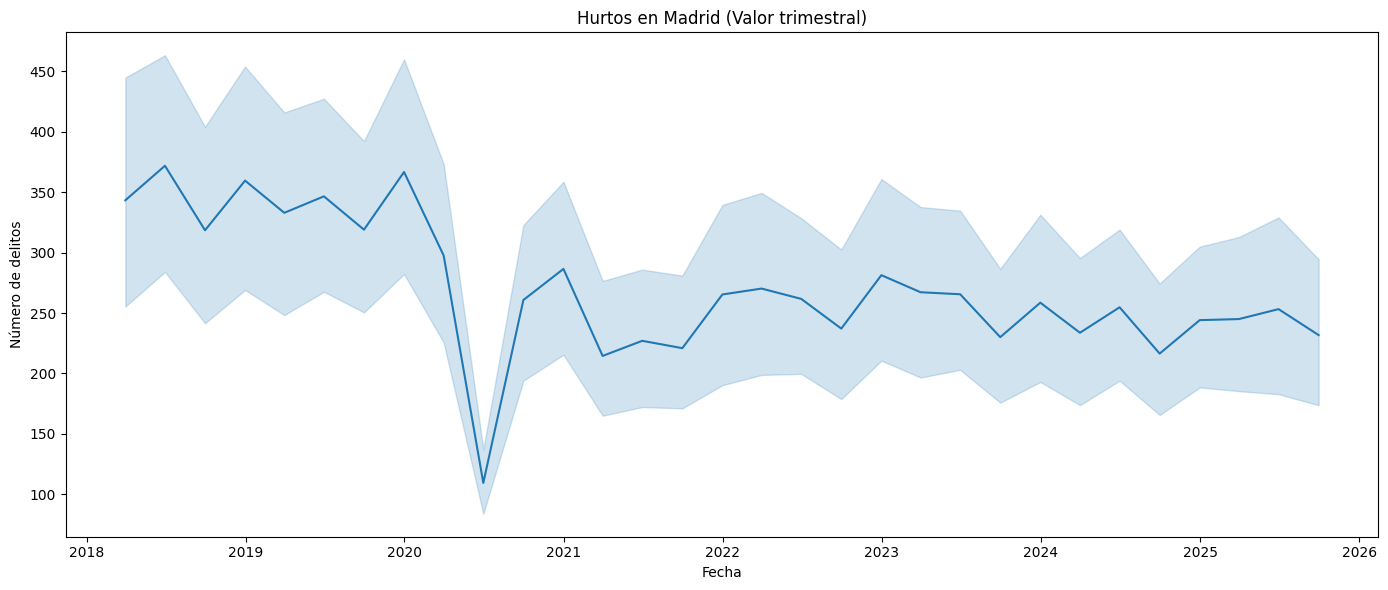

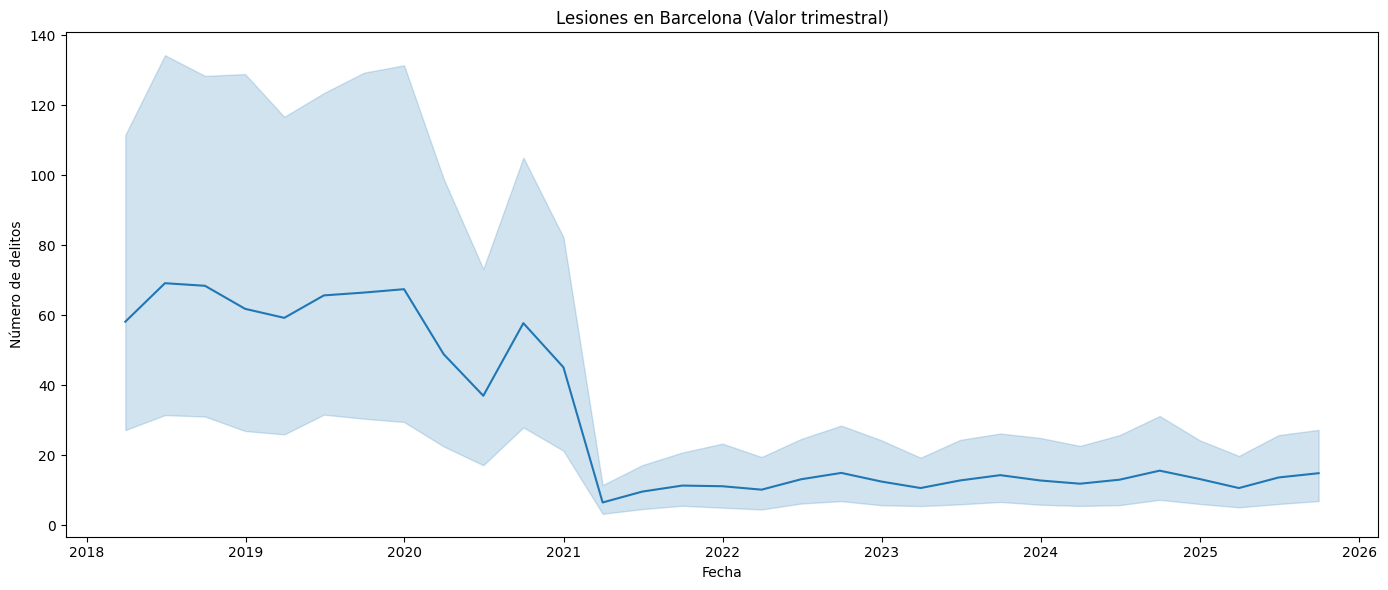

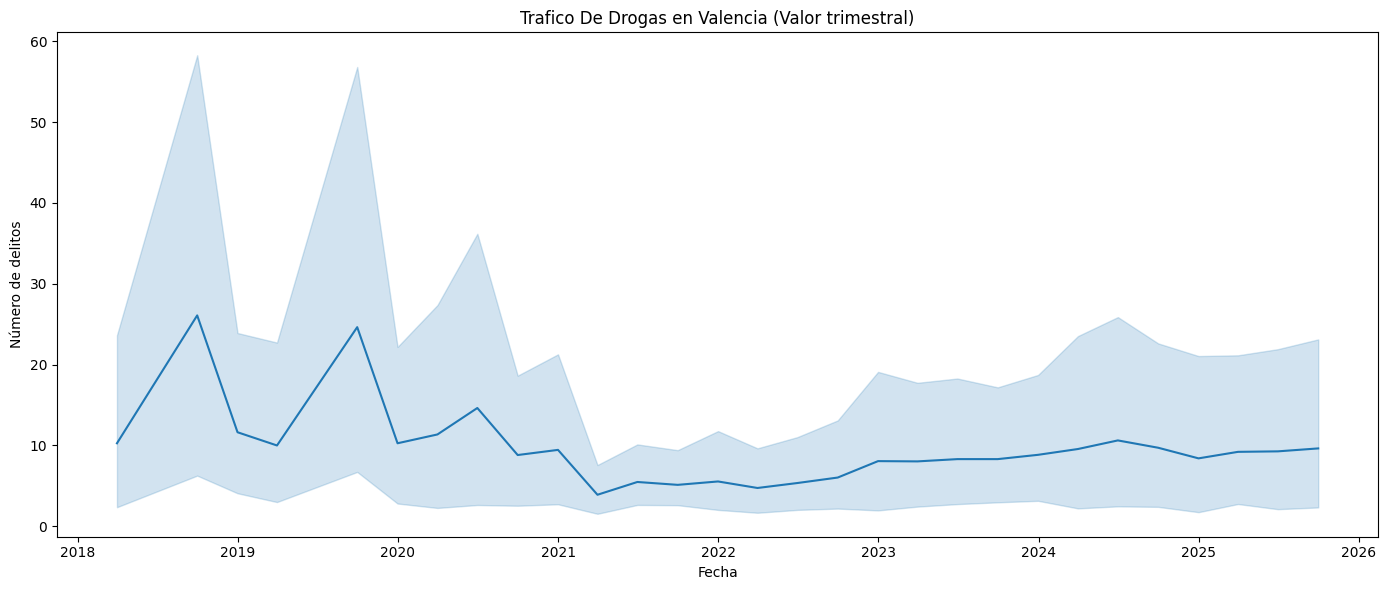

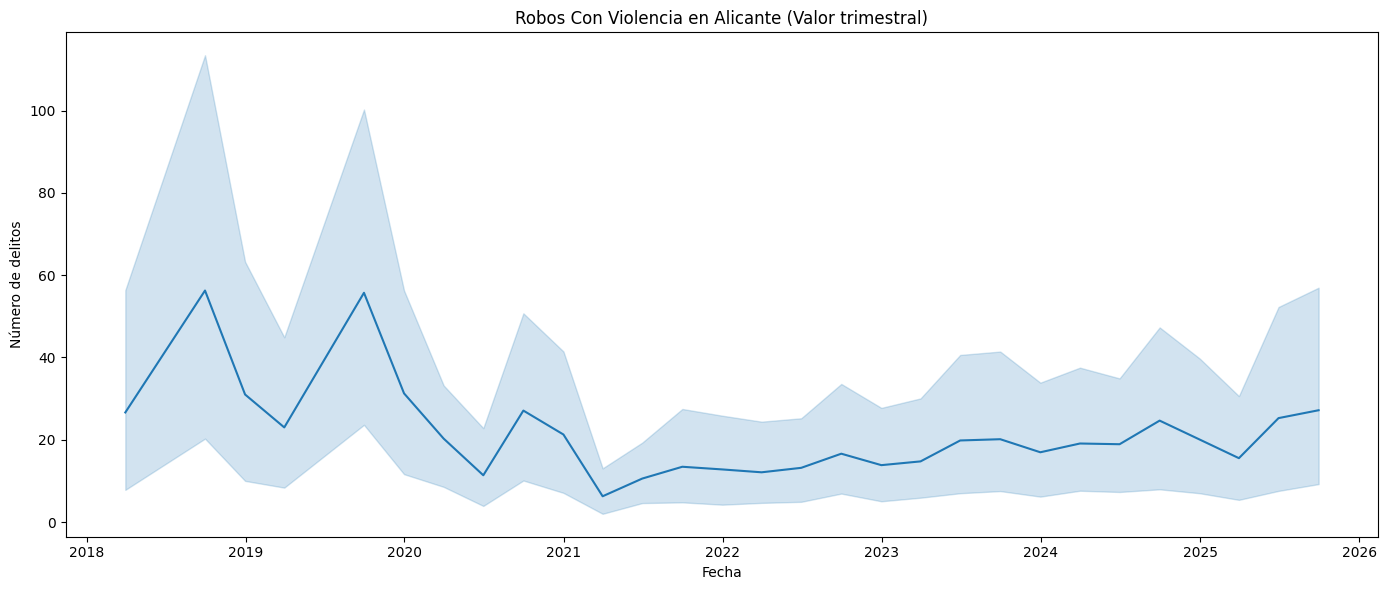

In [1582]:
def plot_delito_provincia(df, provincia, delito):
    # Filtrar por provincia y delito
    subset = df[(df["Provincia"] == provincia) & (df["Delitos"] == delito)]
    
    # Ordenar por fecha
    subset = subset.sort_index()

    # Graficar
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=subset, x=subset.index, y="Valor trimestral")
    
    plt.title(f"{delito} en {provincia} (Valor trimestral)")
    plt.xlabel("Fecha")
    plt.ylabel("Número de delitos")
    plt.tight_layout()
    plt.show()


plot_delito_provincia(df, "Madrid", "Hurtos")
plot_delito_provincia(df, "Barcelona", "Lesiones")
plot_delito_provincia(df, "Valencia", "Trafico De Drogas")
plot_delito_provincia(df, "Alicante", "Robos Con Violencia")


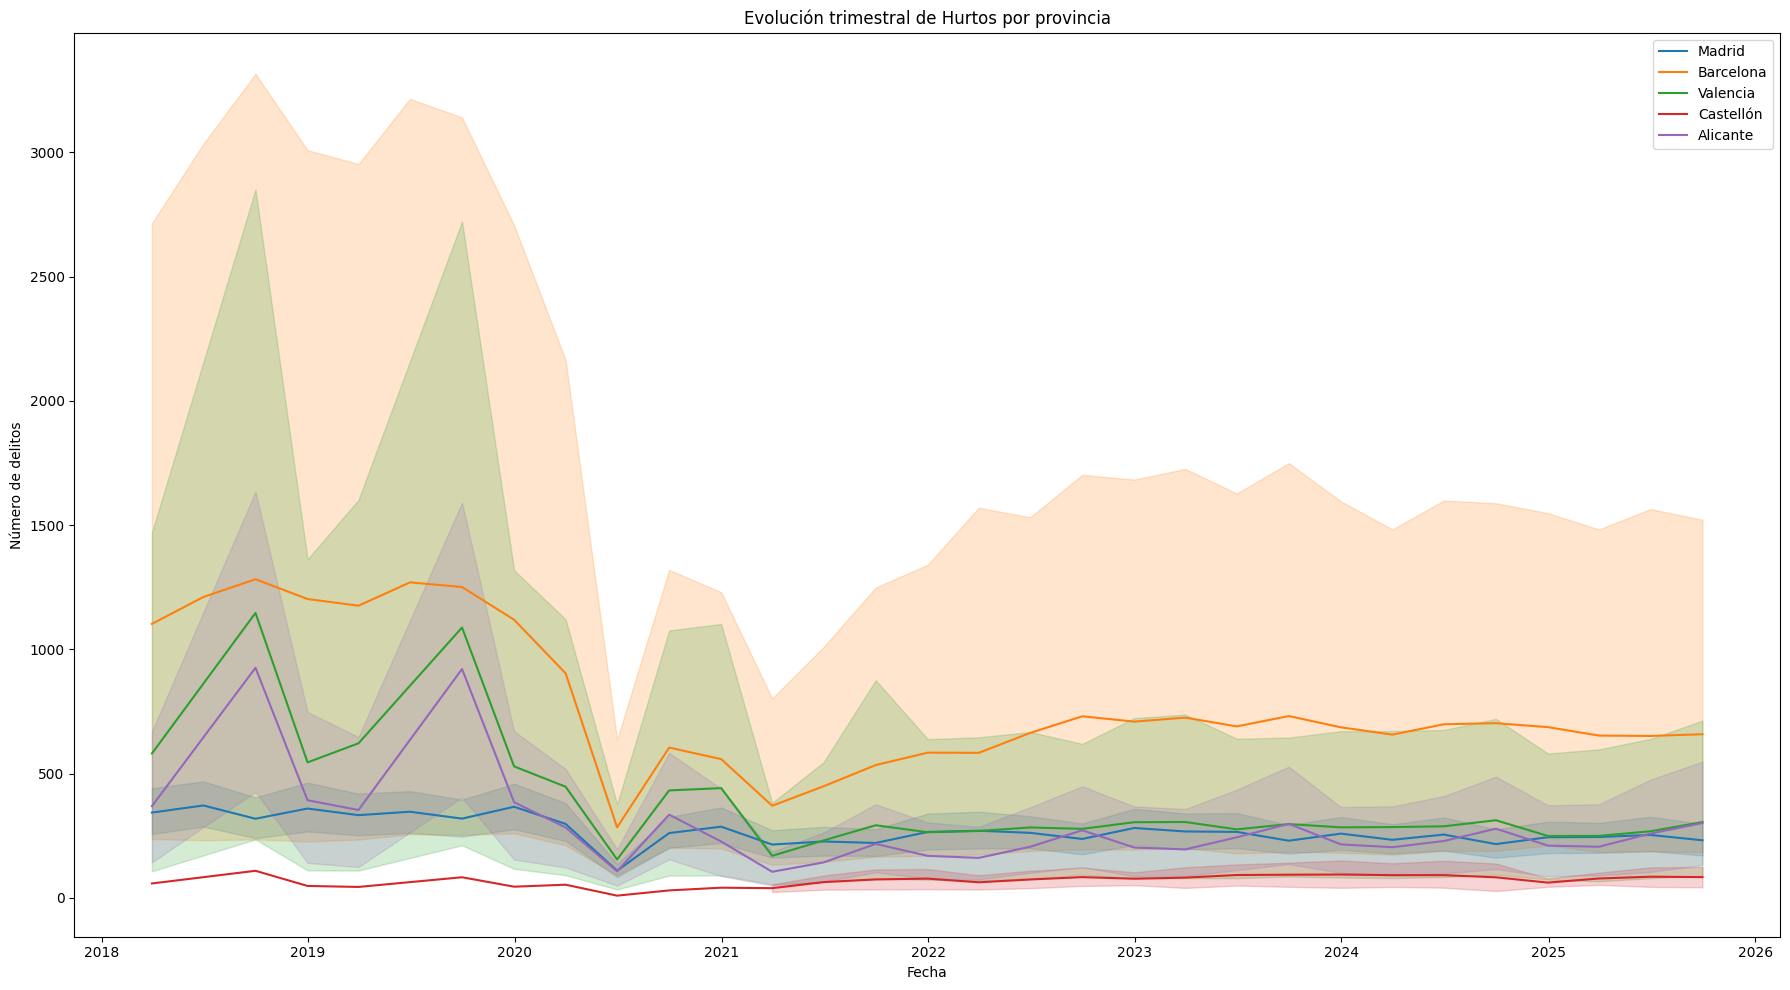

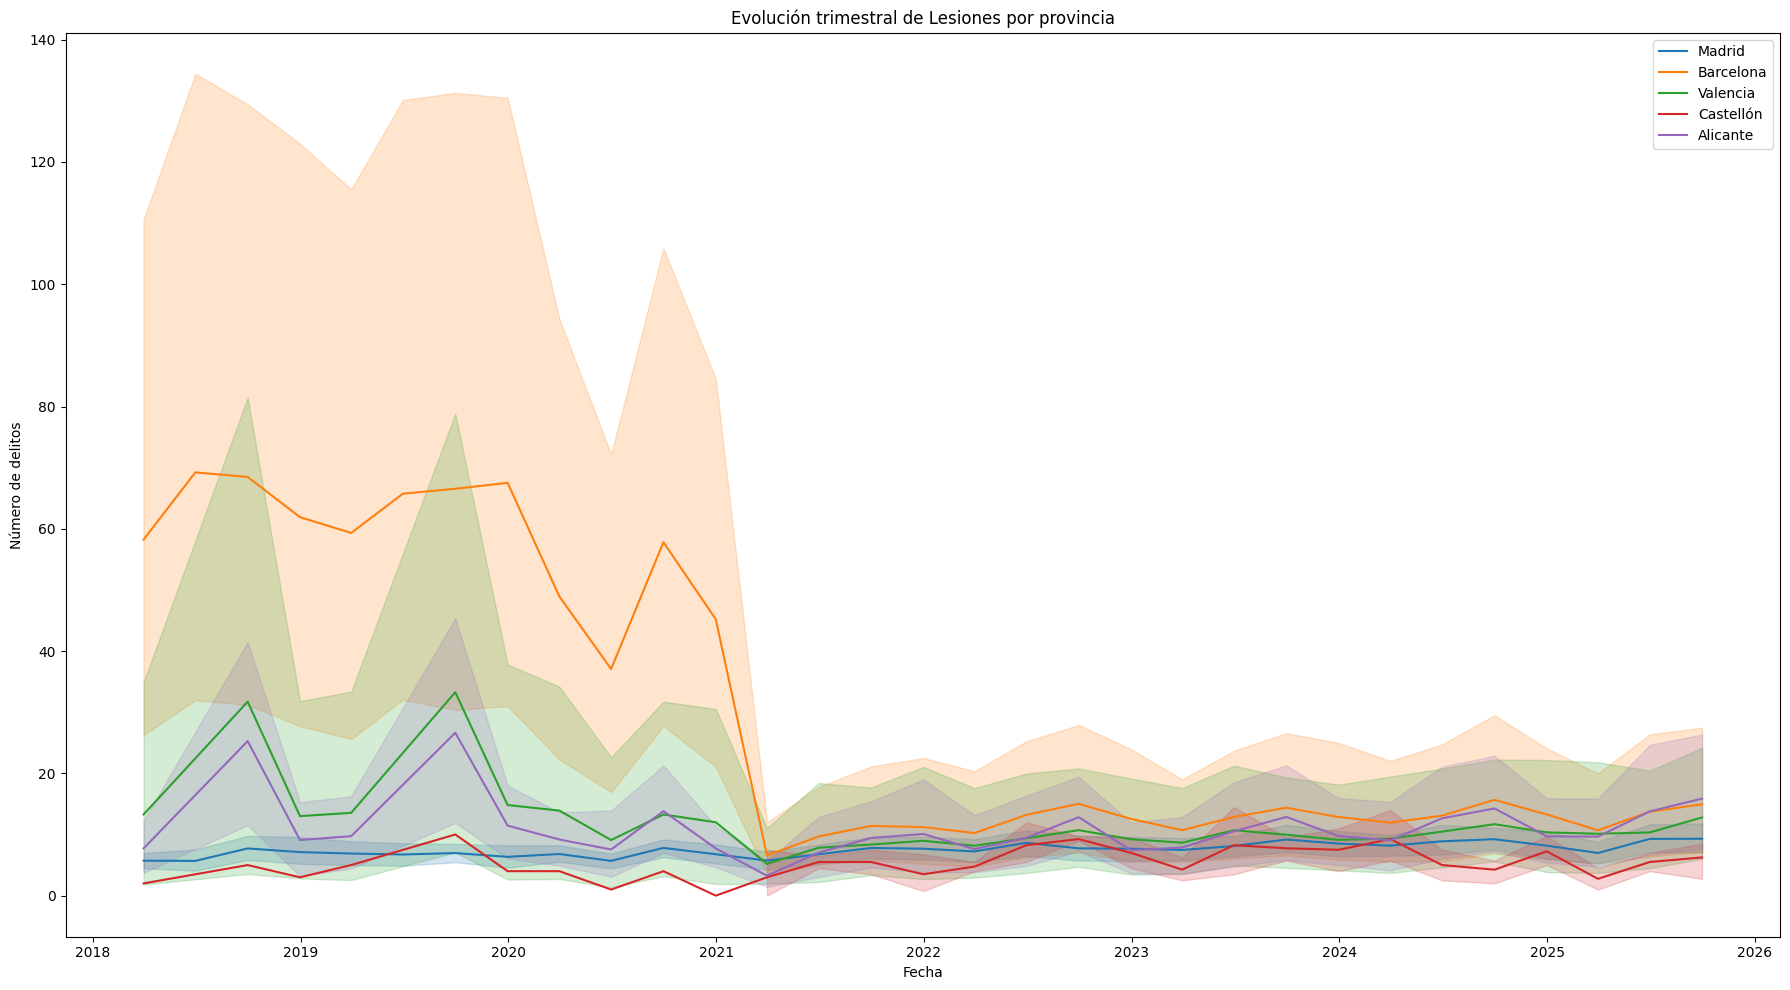

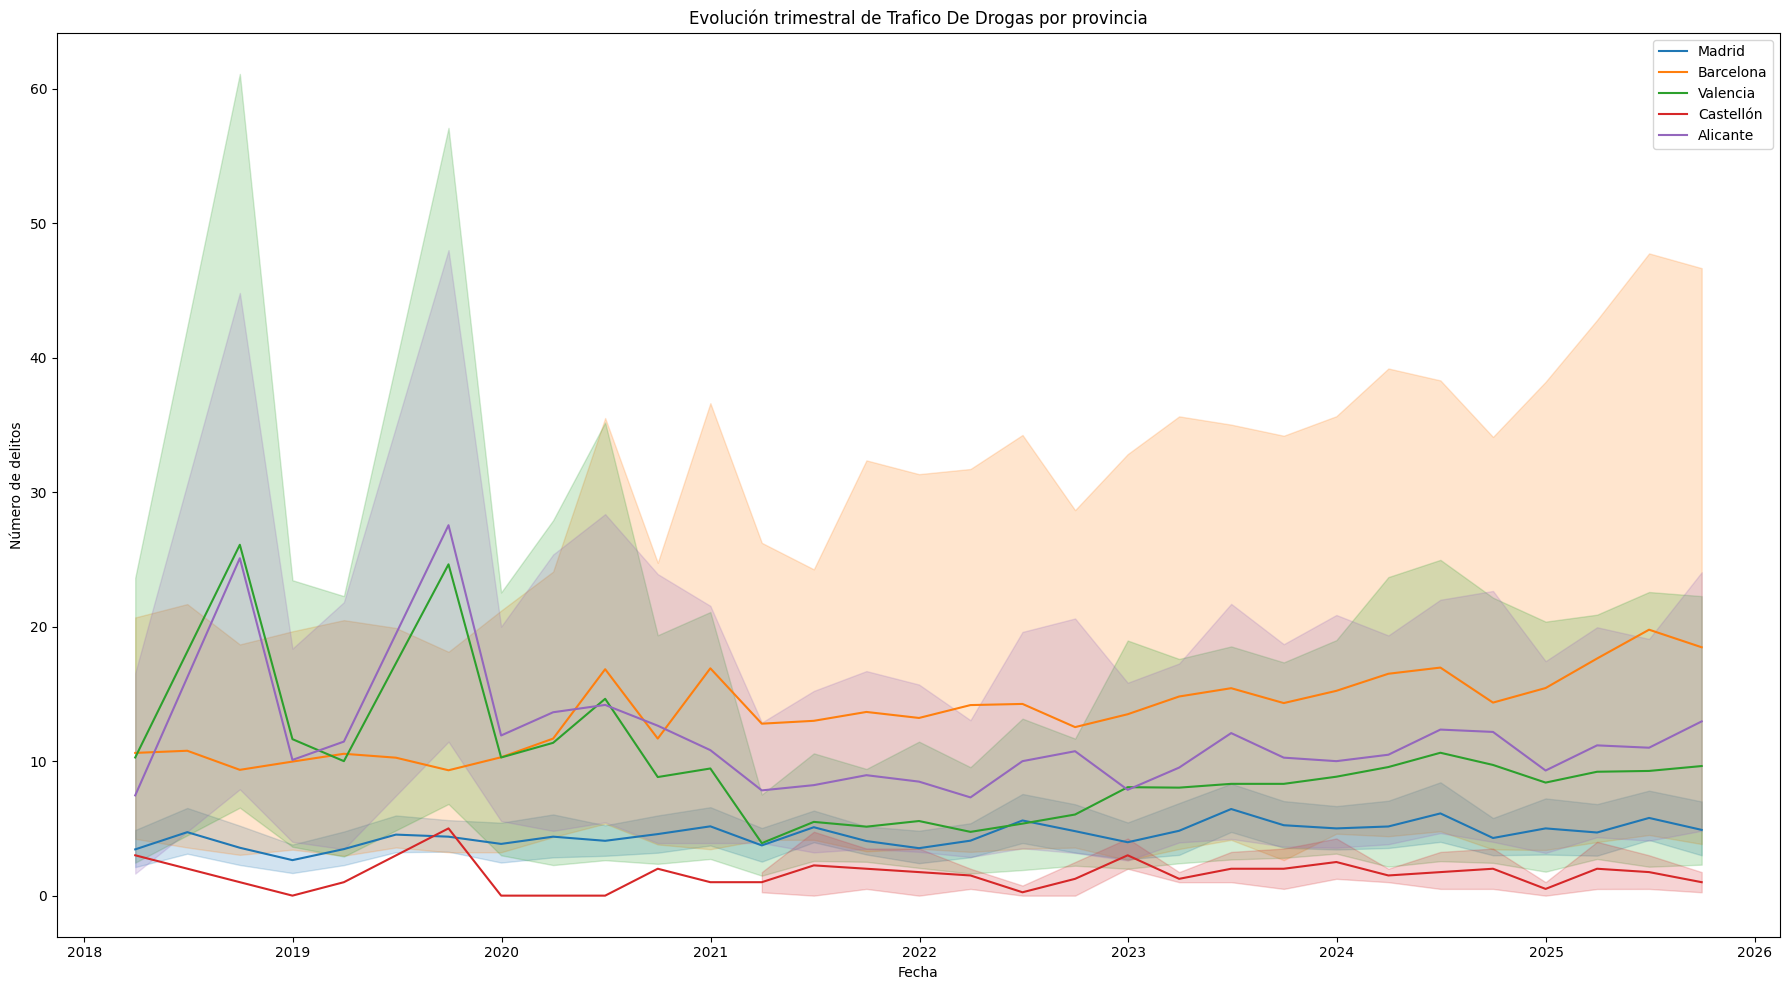

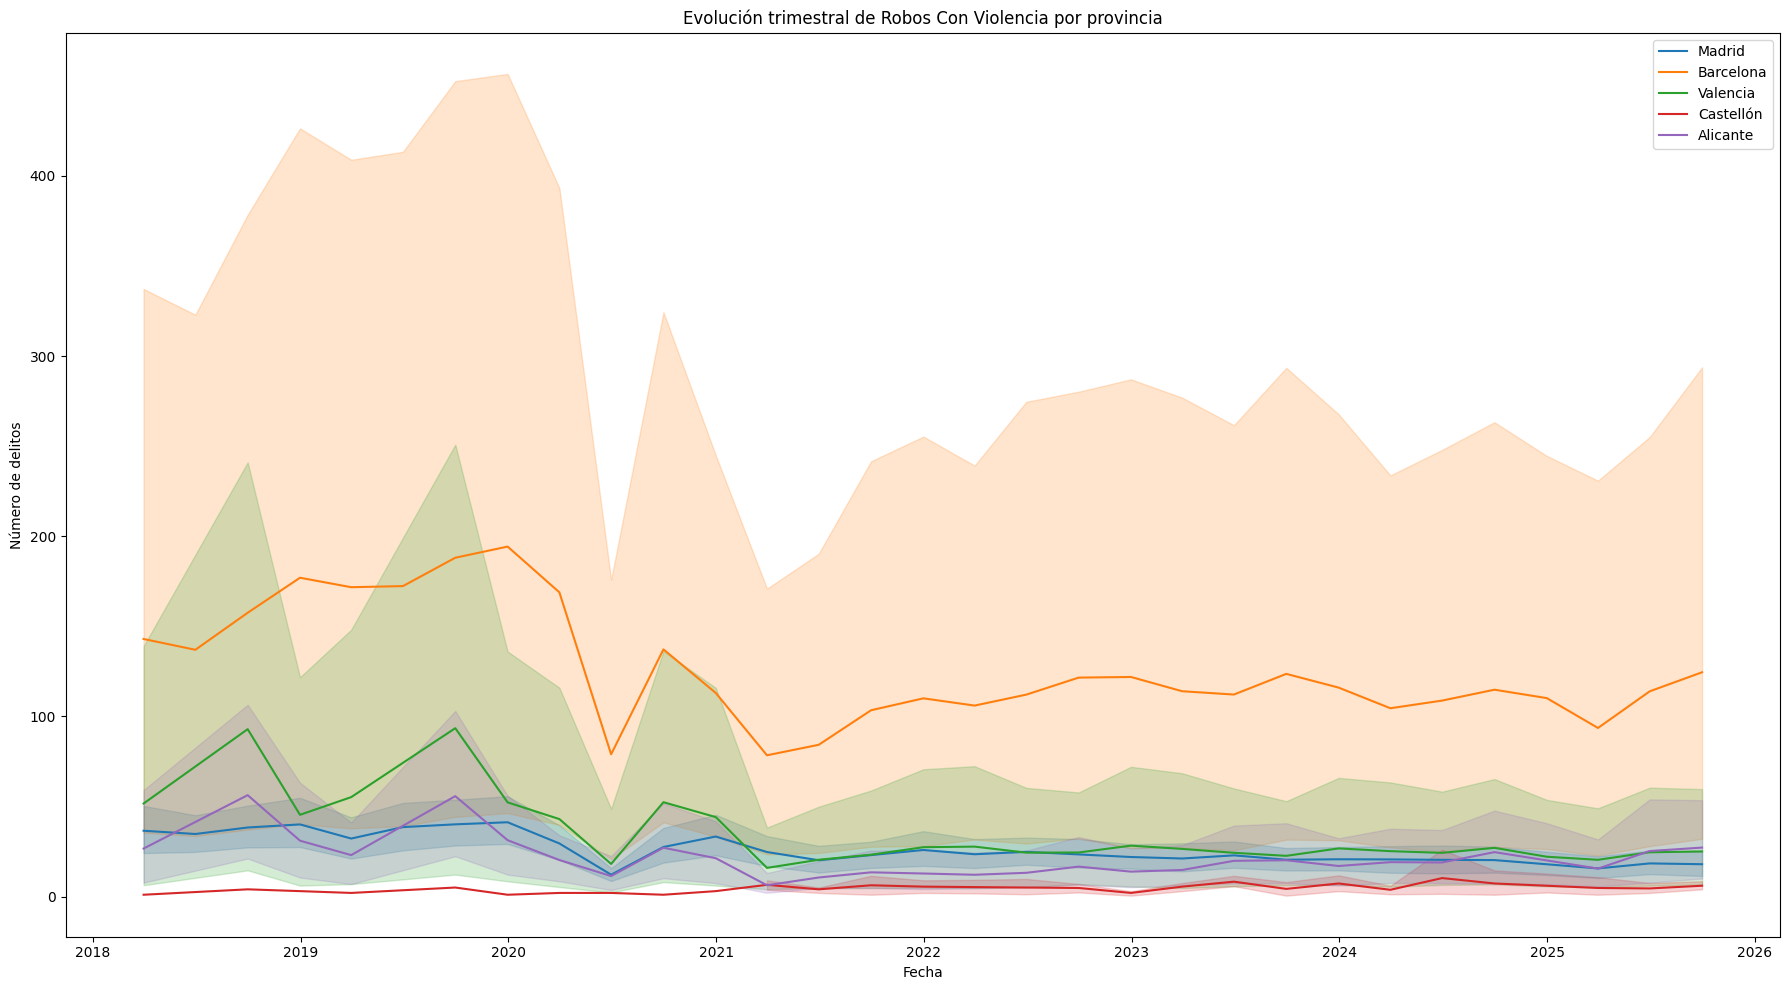

In [1583]:
def comparar_provincias(df, delito, provincias):
    plt.figure(figsize=(18, 10))

    for provincia in provincias:
        subset = df[(df["Provincia"] == provincia) & (df["Delitos"] == delito)]
        subset = subset.sort_index()

        sns.lineplot(
            data=subset,
            x=subset.index,
            y="Valor trimestral",
            label=provincia
        )

    plt.title(f"Evolución trimestral de {delito} por provincia")
    plt.xlabel("Fecha")
    plt.ylabel("Número de delitos")
    plt.tight_layout()
    plt.show()
comparar_provincias(df, "Hurtos", ["Madrid", "Barcelona", "Valencia", "Castellón", "Alicante"])
comparar_provincias(df, "Lesiones", ["Madrid", "Barcelona", "Valencia", "Castellón", "Alicante"])
comparar_provincias(df, "Trafico De Drogas", ["Madrid", "Barcelona", "Valencia", "Castellón", "Alicante"])
comparar_provincias(df, "Robos Con Violencia", ["Madrid", "Barcelona", "Valencia", "Castellón", "Alicante"])


### Problemas

-Podemos ver factores que se repiten pero estos valores estan sesgados por dos principales factores:
1-El ministerio del interior cada año que pasó cubria mas municipios y tomaba en cuenta otros delitos
2-Las provincias que tomamos en cuenta tienen diferencias en la poblacion

### Conclusión

-La solucion a implemnetar es calcular tasas entre delitos y poblacion lo que permite comparar provincias de distinto tamaño, años con distintas coberturas, ver tendencias reales y estacionalidad sin sesgo.

### Conversion poblacion a int para calcular tasas

In [1584]:
df["Poblacion"] = (
    df["Poblacion"]
    .astype(str)                # por si hay valores mixtos
    .str.replace(".", "", regex=False)  # elimina separadores de miles tipo 35.599
    .str.replace(",", ".", regex=False) # convierte coma decimal a punto
)

df["Poblacion"] = pd.to_numeric(df["Poblacion"], errors="coerce")


### Calculo de tasas por 100 mil habitantes

In [1585]:
agg = df.groupby([df.index, "Provincia", "Delitos"]).agg(
    delitos_sum = ("Valor trimestral", "sum"),
    poblacion_sum = ("Poblacion", "sum")
).reset_index().rename(columns={df.index.name: "Fecha"})

agg["tasa_100k"] = (agg["delitos_sum"] / agg["poblacion_sum"]) * 100000


In [1586]:
df[df["Poblacion"].isna()].head()


,Municipio,Delitos,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
fecha,,,,,,,,


In [1587]:
panel = agg.set_index(["Fecha", "Provincia", "Delitos"]).sort_index()
panel.to_csv("../data/processed/df_pre_modelado.csv")


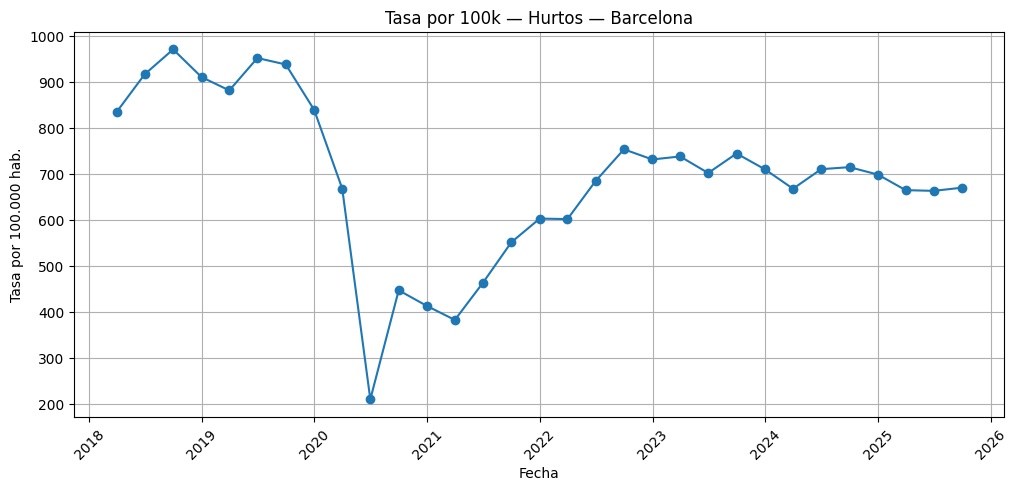

In [1588]:
def plot_tasa(panel, provincia, delito): 
    serie = panel.xs((provincia, delito), level=["Provincia","Delitos"])["tasa_100k"] 
    plt.figure(figsize=(12,5)) 
    plt.plot(serie.index, serie.values, marker="o") 
    plt.title(f"Tasa por 100k — {delito} — {provincia}") 
    plt.xlabel("Fecha") 
    plt.ylabel("Tasa por 100.000 hab.")
    plt.xticks(rotation=45) # Rotación de 45 grados 
    plt.grid(True) 
    plt.show()  
    
plot_tasa(panel, "Barcelona", "Hurtos")

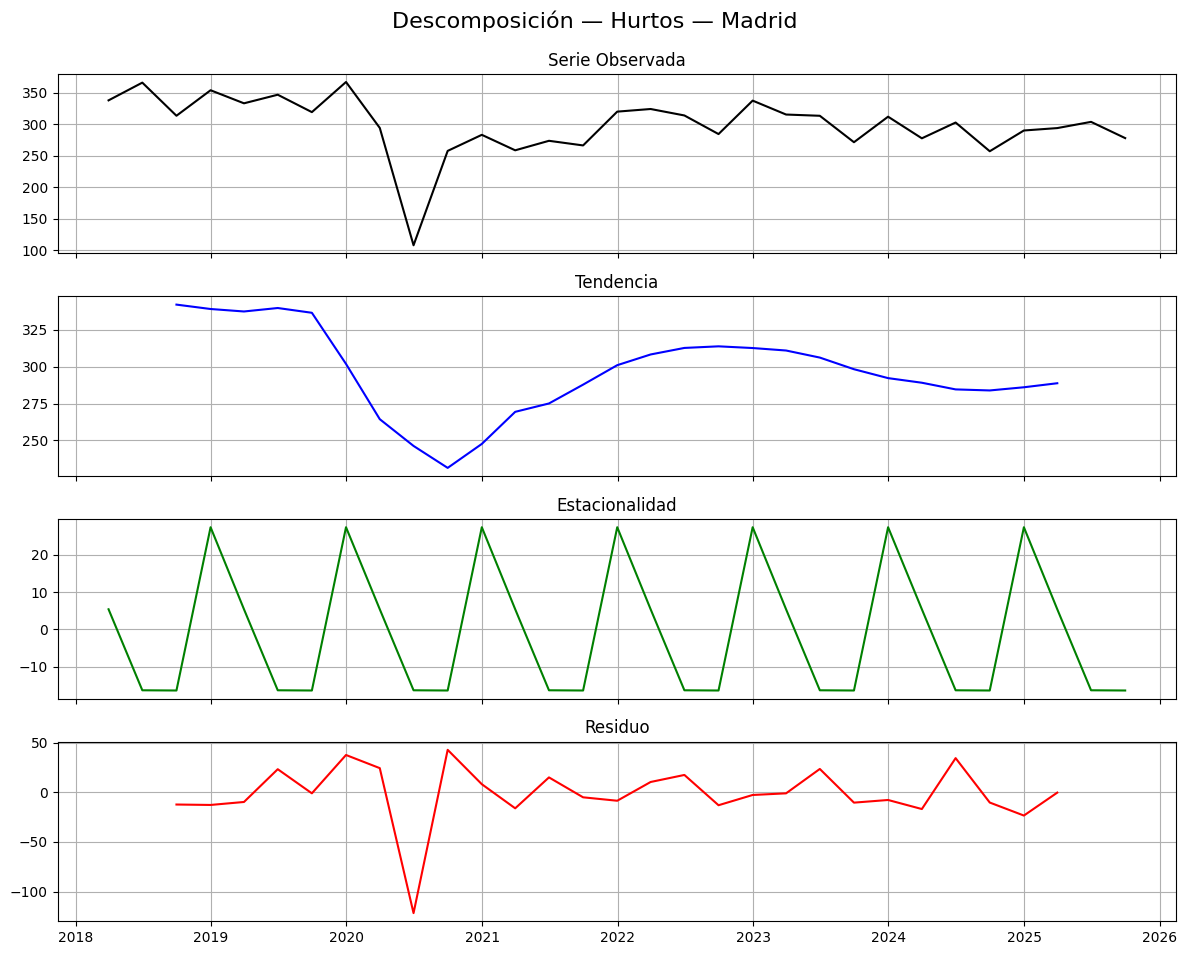

In [1589]:
def descomponer(panel, provincia, delito):
    # Extraer serie porque nuestro df tiene multiindex, es decir, muchas series dentro de una estrcutura
    # Por eso necesitamos extraer una serie concreta y eso hace (xs)
    serie = panel.xs((provincia, delito), level=["Provincia","Delitos"])["tasa_100k"]

    # Asegurar frecuencia trimestral
    serie = serie.asfreq("QE").interpolate()

    # Descomposición
    descomp = seasonal_decompose(serie, model="additive")

    # Crear figura con 4 subplots separados
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Descomposición — {delito} — {provincia}", fontsize=16, y=0.95)

    # Observed
    axes[0].plot(descomp.observed, label="Observado", color="black")
    axes[0].set_title("Serie Observada")
    axes[0].grid(True)

    # Trend
    axes[1].plot(descomp.trend, label="Tendencia", color="blue")
    axes[1].set_title("Tendencia")
    axes[1].grid(True)

    # Seasonal
    axes[2].plot(descomp.seasonal, label="Estacionalidad", color="green")
    axes[2].set_title("Estacionalidad")
    axes[2].grid(True)

    # Residual
    axes[3].plot(descomp.resid, label="Residuo", color="red")
    axes[3].set_title("Residuo")
    axes[3].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


descomponer(panel, "Madrid","Hurtos")

### Conclusiones

-Observamos que el residuo capturó el shock(ruido) en este caso la epoca del covid.

### Test dickey-fuller

-Esta serie es estacionaria? su comportamiento es estable en el tiempo?

H0: la serie no es estacionaria
H1: la serie si es estacionaria

In [1590]:
def dickey_fuller(panel, provincia, delito): 
    serie = panel.xs((provincia, delito), level=["Provincia","Delitos"])["tasa_100k"] 
    serie = serie.asfreq("QE").interpolate() 
    resultado = adfuller(serie) 

    print("ADF Statistic:", resultado[0]) 
    print("p-value:", resultado[1]) 
    print("Critical Values:") 
    
    for key, value in resultado[4].items(): 
        print(f" {key}: {value}")

dickey_fuller(panel, "Madrid", "Hurtos")


ADF Statistic: -2.7646673480789787
p-value: 0.06350071598101005
Critical Values:
 1%: -3.7377092158564813
 5%: -2.9922162731481485
 10%: -2.635746736111111


In [1591]:
df["Delitos"].unique()

<StringArray>
[        'Delitos Sexuales',         'Robos Con Fuerza',
 'Sustraccion De Vehiculos',                 'Lesiones',
        'Trafico De Drogas',                   'Hurtos',
               'Homicidios',      'Robos Con Violencia',
                'Secuestro']
Length: 9, dtype: str

### Diferenciacion y test dickey-fuller sobre serie diferenciada

-Queremos convertir la serie en una serie estacionaria(media y varianza estables en el tiempo)

### Diferenciamos Madrid - Hurtos
-Es la unica que no es estacionaria

In [1592]:
def diferenciacion(panel, provincia, delitos):

    serie = panel.xs((provincia, delitos), level=["Provincia","Delitos"])["tasa_100k"]
    serie = serie.asfreq("QE").interpolate()

    #Eliminamos la tendencia
    serie_diff = serie.diff().dropna()

    test_stationary = adfuller(serie_diff)

    print("ADF Statistic:", test_stationary[0]) 
    print("p-value:", test_stationary[1]) 
    print("Critical Values:") 
    
    for key, value in test_stationary[4].items(): 
        print(f" {key}: {value}")
    

diferenciacion(panel,"Madrid","Hurtos")


ADF Statistic: -2.0992673293137796
p-value: 0.24480931411400636
Critical Values:
 1%: -3.769732625845229
 5%: -3.005425537190083
 10%: -2.6425009917355373


### Conclusiones
-Podemos rechazar la hipotesis nula, la serie Madrid-Hurtos, ahora es estacionaria

### verificacion del residuo post diferenciacion

### ACF(PACF)

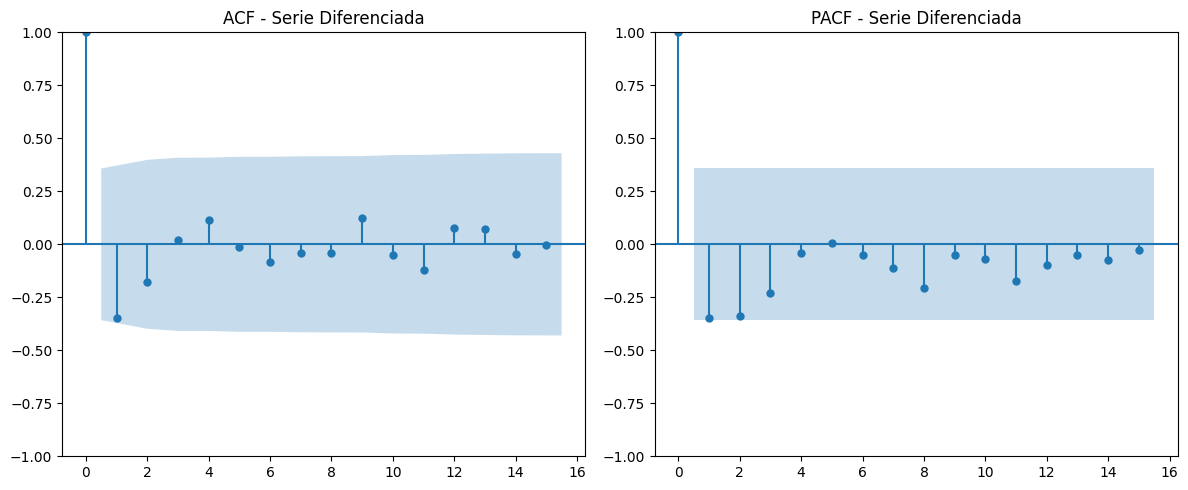

In [1593]:
def acf_pacf_diff(panel,provincia, delito):

    serie = panel.xs((provincia, delito), level=["Provincia","Delitos"])["tasa_100k"]
    serie = serie.asfreq("QE").interpolate()
    serie_diff = serie.diff().dropna()


    fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

    plot_acf(serie_diff, ax=axes[0]) 
    axes[0].set_title("ACF - Serie Diferenciada") 

    plot_pacf(serie_diff, ax=axes[1]) 
    axes[1].set_title("PACF - Serie Diferenciada") 

    plt.tight_layout() 
    plt.show()

acf_pacf_diff(panel,"Madrid","Hurtos")

### Concluisones

-Podemos observar memoria de corto plazo, es decir los datos actuales dependen un pocoi de loq ue pasó el trimestree anterior
-Compoennte MA1. El error del trimestre pasado influye en el valor del trimestre actual. Ese pico en el lag 1 representa un shock que deja un "eco" que afecta el trimestre actual, pero ese eco, solo dura un trimestre

### Creamos la dummy COVID para capturar el shock

In [1594]:
panel["dummy_covid"] = (
    panel.index.get_level_values("Fecha") >= "2020-03-01"
).astype(int)


### Funcion auxiliar de metricas

In [1595]:
def get_regression_metrics(y_predict_test, y_test, y_predict_train, y_train):
    """
    get_regression_metrics Hector
        y_predict_test: dataFrame, con los datos para ypredict
        Hola mundo
    """
    metrics_train = (r2_score(y_train, y_predict_train),
                     median_absolute_error(y_train, y_predict_train),
                     mean_absolute_percentage_error(y_train, y_predict_train) * 100,
                     mean_squared_error(y_train, y_predict_train),
                     root_mean_squared_error(y_train, y_predict_train))
    metrics_test = (r2_score(y_test, y_predict_test),
                    median_absolute_error(y_test, y_predict_test),
                    mean_absolute_percentage_error(y_test, y_predict_test) * 100,
                    mean_squared_error(y_test, y_predict_test),
                    root_mean_squared_error(y_test, y_predict_test))
    metrics_diff = list(map(lambda x: x[1] - x[0], zip(metrics_train, metrics_test)))
    return pd.DataFrame(data=[metrics_train, metrics_test, metrics_diff],
                        columns=['R2', 'MAE', 'MAPE', 'MSE', 'RMSE'],
                        index=['Train set', 'Test set', 'Difference'])

### SARIMAX
-Devuelve el modelo entrenado solo con train. Comprobamos si el modleo funciona

In [1596]:
def validar_sarimax(panel, provincia, delito, order=(0,1,1),seasonal_order=(1,0,0,4),trend=None):

    # 1. Extraer serie y dummy
    serie = panel.xs((provincia, delito), level=["Provincia","Delitos"])["tasa_100k"].asfreq("QE").interpolate()
    dummy = panel.xs((provincia, delito), level=["Provincia","Delitos"])["dummy_covid"].asfreq("QE").interpolate()

    # 2. Split
    train = serie.loc[:'2024Q4']
    test  = serie.loc['2025Q1':'2025Q3']

    dummy_train = dummy.loc[:'2024Q4']
    dummy_test  = dummy.loc['2025Q1':'2025Q3']

    # 3. Entrenar SOLO con train
    modelo = SARIMAX(
        train,
        exog=dummy_train,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    # 4. Predicción test
    pred_test = modelo.get_forecast(steps=len(test), exog=dummy_test).predicted_mean
    pred_test.index = test.index

    # 5. Predicción train (in-sample)
    pred_train = modelo.get_prediction(start=train.index[0], end=train.index[-1], exog=dummy_train).predicted_mean
    pred_train.index = train.index

    return {
        "modelo": modelo,
        "train": train,
        "test": test,
        "pred_train": pred_train,
        "pred_test": pred_test
    }


### Entrenamos SARIMAX 

In [1597]:
def entrenar_sarimax(panel, provincia, delito, order=(0,1,1),seasonal_order=(1,0,0,4),trend=None):

    serie = panel.xs((provincia, delito), level=["Provincia","Delitos"])["tasa_100k"].asfreq("QE").interpolate()
    dummy = panel.xs((provincia, delito), level=["Provincia","Delitos"])["dummy_covid"].asfreq("QE").interpolate()

    modelo = SARIMAX(
        serie,
        exog=dummy,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    return modelo


### Lista de provincias

In [1598]:
provincias = panel.index.get_level_values("Provincia").unique()

### Llamamos validar_sarimax, calculamos metricas y guardamos resultados

In [1599]:
validaciones = {}

for prov in provincias:
    res = validar_sarimax(panel, prov, "Hurtos")
    
    metrics = get_regression_metrics(
        res["pred_test"], res["test"],
        res["pred_train"], res["train"]
    )
    
    validaciones[prov] = {
        "res": res,
        "metrics": metrics
    }

### Entrenamos el modelo con TODA la serie

In [1600]:
modelos_finales = {}

for prov in provincias:
    modelo_final = entrenar_sarimax(panel, prov, "Hurtos")
    modelos_finales[prov] = modelo_final

### predecimos siguientes años

In [1601]:
resultados = {}

for prov in provincias:
    modelo = modelos_finales[prov]
    
    pred = modelo.get_forecast(steps=8, exog=np.ones((8,1)))
    pred_ci = pred.conf_int()
    
    resultados[prov] = {
        "prediccion": pred.predicted_mean,
        "intervalo": pred_ci,
        "serie": panel.xs((prov, "Hurtos"), level=["Provincia","Delitos"])["tasa_100k"].asfreq("QE").interpolate()
    }

### Funcion de graficado

In [1602]:
def graficar_prediccion(resultados, provincia):
    serie = resultados[provincia]["serie"]
    pred = resultados[provincia]["prediccion"]
    pred_ci = resultados[provincia]["intervalo"]

    ax = serie.plot(label="Observado", figsize=(10,5), title=f"Predicción para {provincia}")
    pred.plot(ax=ax, label="Predicción")
    ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], alpha=0.2)
    ax.legend()
    return ax


# Validacion predice bien los datos que conozco, 2025?

In [1603]:
pd.DataFrame({
    "real": validaciones["Madrid"]["res"]["test"],
    "predicho": validaciones["Madrid"]["res"]["pred_test"]
})




,real,predicho
Fecha,,
2025-03-31,293.861327,283.228339
2025-06-30,303.722221,287.939327
2025-09-30,277.970628,279.367503


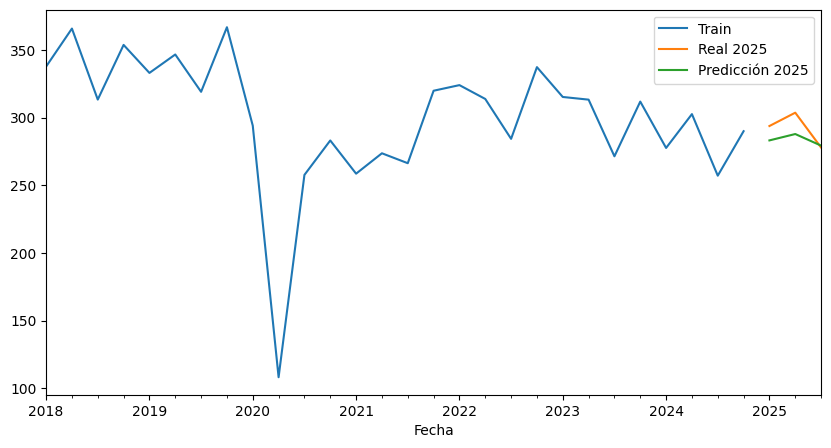

In [1604]:
prov = "Madrid"
res = validaciones[prov]["res"]

ax = res["train"].plot(label="Train", figsize=(10,5))
res["test"].plot(ax=ax, label="Real 2025")
res["pred_test"].plot(ax=ax, label="Predicción 2025")
ax.legend()


### Prediccion futura

<Axes: title={'center': 'Predicción para Madrid'}, xlabel='Fecha'>

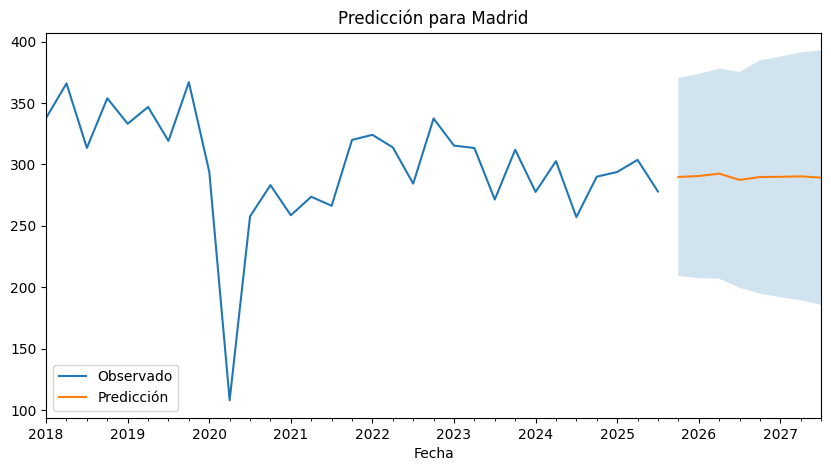

In [1605]:
graficar_prediccion(resultados, "Madrid")

In [1606]:
modelo_madrid = entrenar_sarimax(panel, "Madrid", "Hurtos")
modelo_barcelona = entrenar_sarimax(panel, "Barcelona", "Hurtos")
modelo_valencia = entrenar_sarimax(panel, "Valencia", "Hurtos")
modelo_castellon = entrenar_sarimax(panel, "Castellón", "Hurtos")
modelo_alicante = entrenar_sarimax(panel, "Alicante", "Hurtos")


In [1607]:
with open("../models/modelo_madrid.pkl", "wb") as f:
    pickle.dump(modelo_madrid, f)

with open("../models/modelo_barcelona.pkl", "wb") as f:
    pickle.dump(modelo_barcelona, f)

with open("../models/modelo_valencia.pkl", "wb") as f:
    pickle.dump(modelo_valencia, f)

with open("../models/modelo_castellon.pkl", "wb") as f:
    pickle.dump(modelo_castellon, f)

with open("../models/modelo_alicante.pkl", "wb") as f:
    pickle.dump(modelo_alicante, f)

